In [2]:
# ============================================================
# CELL 1 - Install dependencies
# ============================================================
!pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 18.0 MB/s eta 0:00:00a 0:00:01


In [4]:
# ============================================================
# CELL 2 - Verify GPU & imports
# ============================================================
import torch
import os
from ultralytics import YOLO

print(f"CUDA available: {torch.cuda.is_available()}")
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

CUDA available: True
GPU: Tesla T4
VRAM: 15.6 GB


In [5]:
import torch
print(f"GPUs available: {torch.cuda.device_count()}")  # Should print: 2
print(f"GPU 0: {torch.cuda.get_device_name(0)}")
print(f"GPU 1: {torch.cuda.get_device_name(1)}")

GPUs available: 2
GPU 0: Tesla T4
GPU 1: Tesla T4


In [6]:
# ============================================================
# CELL 3 - Check dataset structure
# ============================================================
dataset_path = "/kaggle/input/datasets/thedatasith/sku110k-annotations/SKU110K_fixed"  # update if different

for split in ["train", "val", "test"]:
    img_count = len(os.listdir(f"{dataset_path}/images/{split}"))
    lbl_count = len(os.listdir(f"{dataset_path}/labels/{split}"))
    print(f"{split}: {img_count} images, {lbl_count} labels")

train: 8185 images, 8185 labels
val: 584 images, 584 labels
test: 2920 images, 2920 labels


In [8]:
# ============================================================
# CELL 4 - Create data.yaml (overrides the kaggle one)
# ============================================================
yaml_content = f"""
path: {dataset_path}
train: images/train
val: images/val
test: images/test

nc: 1
names: ['object']
"""

yaml_path = "/kaggle/working/sku110k.yaml"
with open(yaml_path, "w") as f:
    f.write(yaml_content)

print("data.yaml created:")
print(yaml_content)

data.yaml created:

path: /kaggle/input/datasets/thedatasith/sku110k-annotations/SKU110K_fixed
train: images/train
val: images/val
test: images/test

nc: 1
names: ['object']



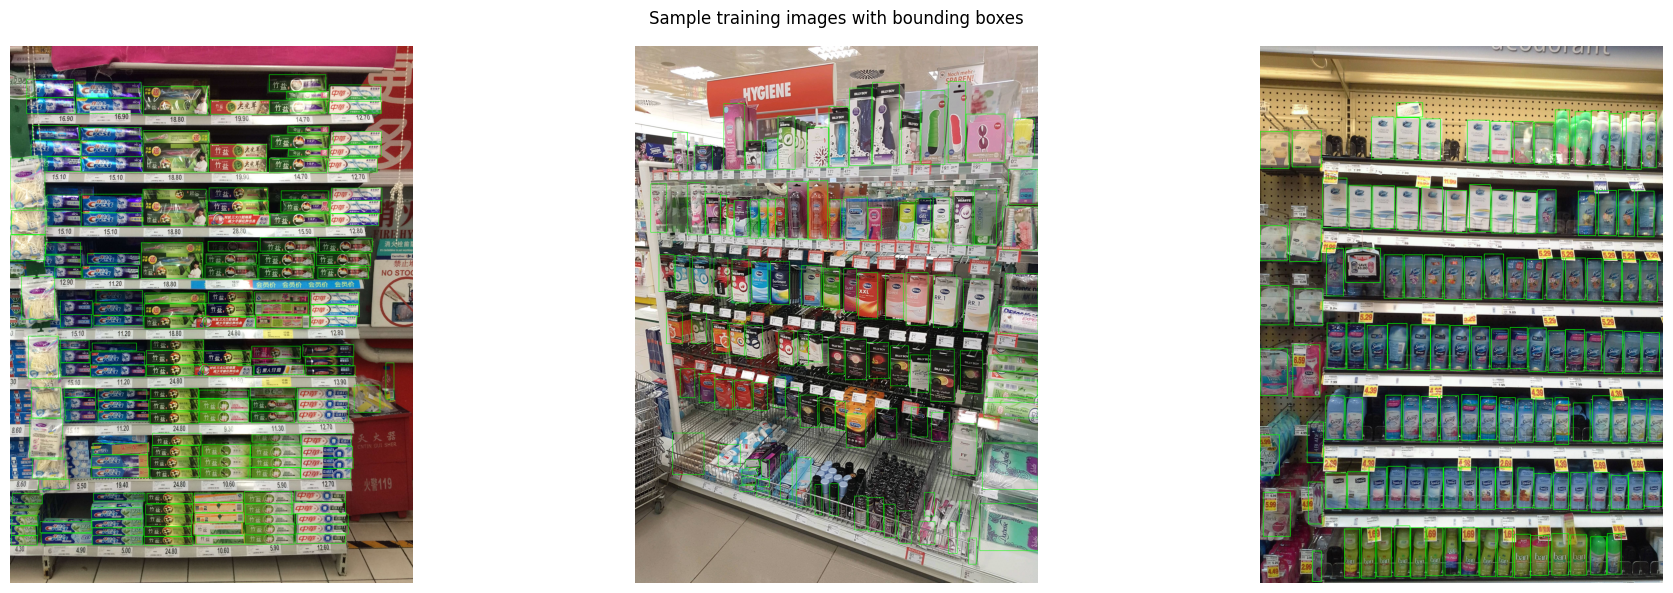

In [9]:
# ============================================================
# CELL 5 - Sanity check: visualize a few images with labels
# ============================================================
import cv2
import matplotlib.pyplot as plt
import numpy as np
import random

def draw_boxes(img_path, label_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    if os.path.exists(label_path):
        with open(label_path) as f:
            for line in f.readlines():
                cls, cx, cy, bw, bh = map(float, line.strip().split())
                x1 = int((cx - bw/2) * w)
                y1 = int((cy - bh/2) * h)
                x2 = int((cx + bw/2) * w)
                y2 = int((cy + bh/2) * h)
                cv2.rectangle(img, (x1,y1), (x2,y2), (0,255,0), 2)
    return img

train_imgs = os.listdir(f"{dataset_path}/images/train")
sample = random.sample(train_imgs, 3)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, fname in zip(axes, sample):
    img_path = f"{dataset_path}/images/train/{fname}"
    lbl_path = f"{dataset_path}/labels/train/{fname.replace('.jpg', '.txt')}"
    ax.imshow(draw_boxes(img_path, lbl_path))
    ax.axis('off')
plt.suptitle("Sample training images with bounding boxes")
plt.tight_layout()
plt.show()

In [10]:
# ============================================================
# CELL 6 - Train YOLOv8s
# ============================================================
model = YOLO("yolov8s.pt")  # downloads pretrained weights

results = model.train(
    data=yaml_path,
    epochs=30,
    imgsz=640,
    batch=16, # safe for T4 16GB, increase to 32 if no OOM
    amp = True,
    device=[0, 1],
    workers=4,
    patience=10,        # early stopping if no improvement for 10 epochs
    save=True,
    save_period=10,     # save checkpoint every 10 epochs
    project="/kaggle/working/runs",
    name="sku110k_v1",

    # Optimizer
    optimizer="AdamW",
    lr0=0.001,
    weight_decay=0.0005,

    # Augmentation (important for shelf/dense detection)
    mosaic=1.0,
    mixup=0.1,
    copy_paste=0.1,
    degrees=5.0,
    translate=0.1,
    scale=0.5,
    fliplr=0.5,

    # Dense detection specific
    overlap_mask=True,
    nms=True,
)

print("Training complete!")

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
                                                      CUDA:1 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/sku110k.yaml, degrees=5.0, deterministic=True, device=0,1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=sku110k_v1, nbs=64, nms=True, opse

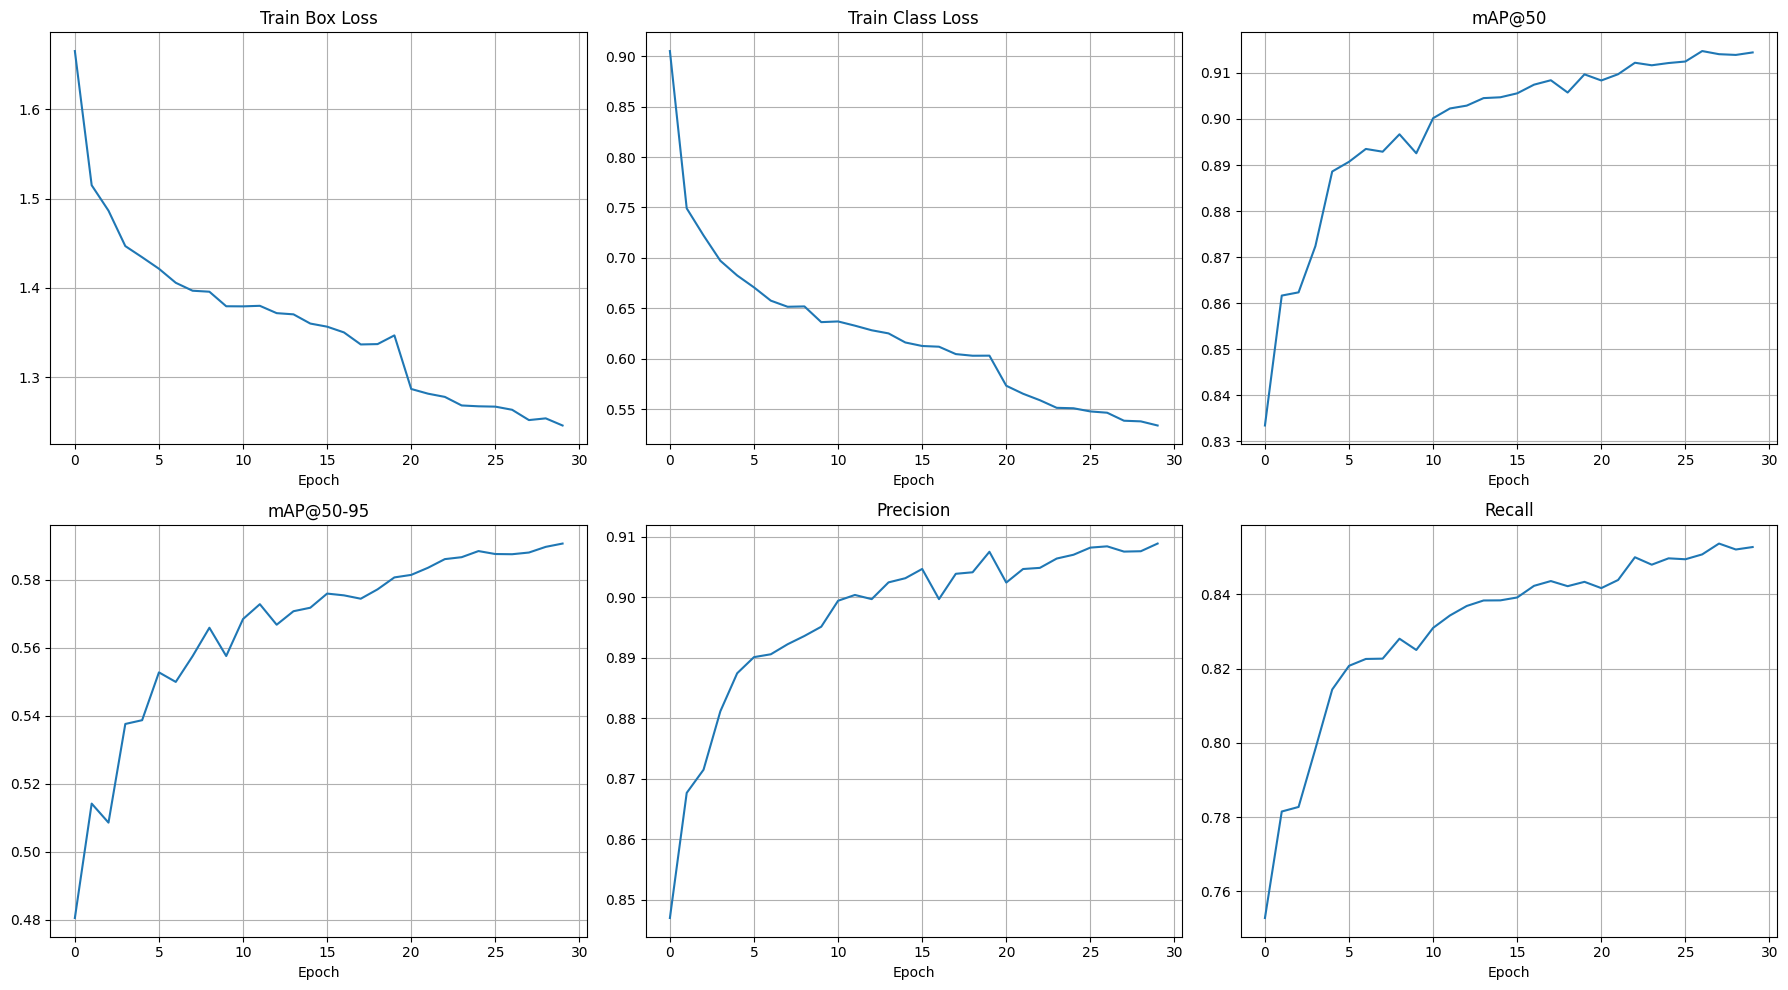

In [11]:
# ============================================================
# CELL 7 - Plot training results
# ============================================================
import pandas as pd
import matplotlib.pyplot as plt

results_csv = "/kaggle/working/runs/sku110k_v1/results.csv"
df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

metrics = [
    ("train/box_loss", "Train Box Loss"),
    ("train/cls_loss", "Train Class Loss"),
    ("metrics/mAP50(B)", "mAP@50"),
    ("metrics/mAP50-95(B)", "mAP@50-95"),
    ("metrics/precision(B)", "Precision"),
    ("metrics/recall(B)", "Recall"),
]

for ax, (col, title) in zip(axes.flat, metrics):
    if col in df.columns:
        ax.plot(df[col])
        ax.set_title(title)
        ax.set_xlabel("Epoch")
        ax.grid(True)

plt.tight_layout()
plt.savefig("/kaggle/working/training_metrics.png")
plt.show()

In [12]:
# ============================================================
# CELL 8 - Evaluate on validation set
# ============================================================
best_model = YOLO("/kaggle/working/runs/sku110k_v1/weights/best.pt")

metrics = best_model.val(
    data=yaml_path,
    imgsz=640,
    batch=16,
    device=0,
    conf=0.25,
    iou=0.45,
)

print(f"\n{'='*40}")
print(f"mAP@50:    {metrics.box.map50:.4f}")
print(f"mAP@50-95: {metrics.box.map:.4f}")
print(f"Precision: {metrics.box.mp:.4f}")
print(f"Recall:    {metrics.box.mr:.4f}")
print(f"{'='*40}")

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1469.3±706.7 MB/s, size: 1467.8 KB)
val: Scanning /kaggle/input/datasets/thedatasith/sku110k-annotations/SKU110K_fixed/labels/val... 584 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 584/584 547.2it/s 1.1s0.0s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/thedatasith/sku110k-annotations/SKU110K_fixed/labels is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 5% ╸─────────── 2/37 2.9s/it 7.2s<1:43WARNING ⚠️ NMS time limit 2.800s exceeded
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 37/37 1.3it/s 27.9s0.4s
                   all        584      90456      0.907      0.846      0.906      0.609
Speed: 0.7ms preprocess, 6.9ms infere

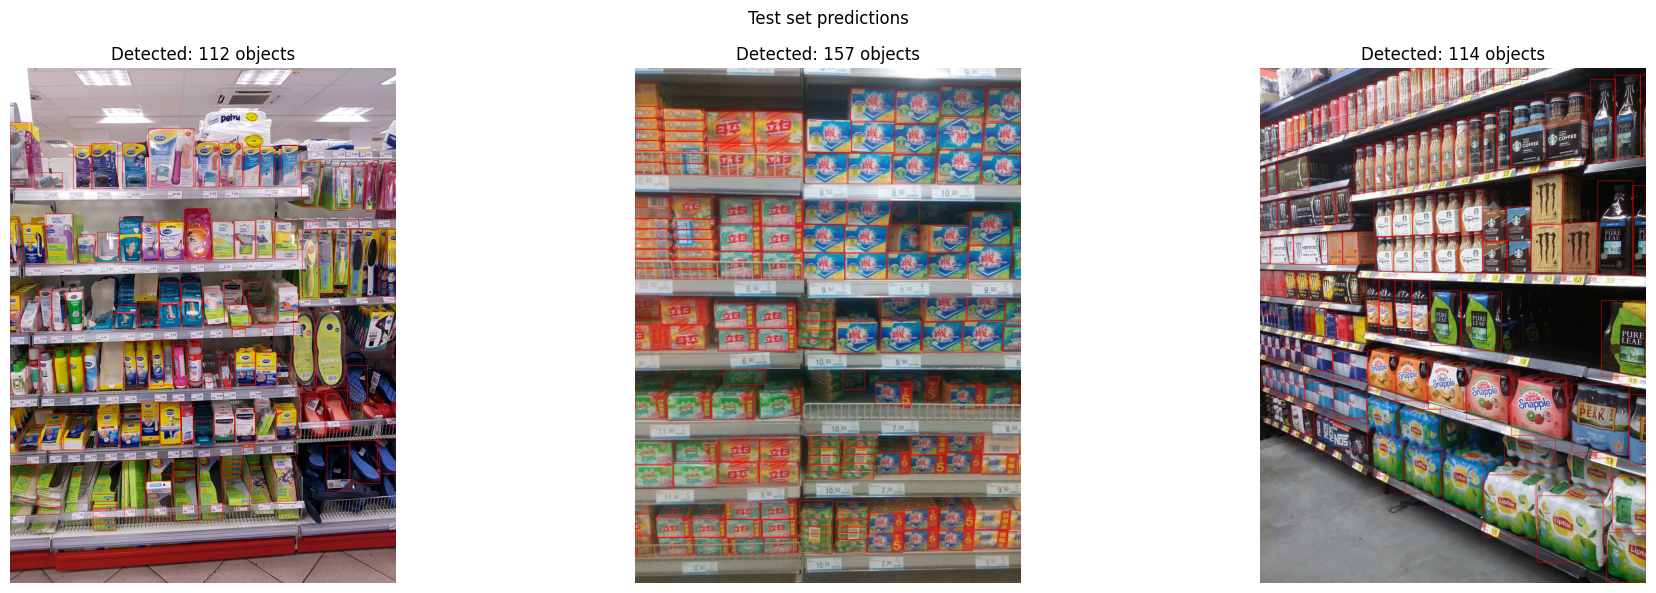

In [13]:
# ============================================================
# CELL 9 - Run inference on test images
# ============================================================
test_imgs = os.listdir(f"{dataset_path}/images/test")
sample_test = random.sample(test_imgs, 3)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, fname in zip(axes, sample_test):
    img_path = f"{dataset_path}/images/test/{fname}"
    result = best_model(img_path, conf=0.25, iou=0.45, verbose=False)[0]
    
    # Draw predictions
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    for box in result.boxes.xyxy.cpu().numpy():
        x1, y1, x2, y2 = map(int, box)
        cv2.rectangle(img, (x1,y1), (x2,y2), (255,0,0), 2)
    
    ax.imshow(img)
    ax.set_title(f"Detected: {len(result.boxes)} objects")
    ax.axis('off')

plt.suptitle("Test set predictions")
plt.tight_layout()
plt.savefig("/kaggle/working/test_predictions.png")
plt.show()

In [14]:
# ============================================================
# CELL 10 - Save best model weights for next notebook
# ============================================================
import shutil

shutil.copy(
    "/kaggle/working/runs/sku110k_v1/weights/best.pt",
    "/kaggle/working/sku110k_best.pt"
)

print("Model saved to /kaggle/working/sku110k_best.pt")
print("Go to Notebook Output to download or use in next notebook")

Model saved to /kaggle/working/sku110k_best.pt
Go to Notebook Output to download or use in next notebook


In [21]:
# ============================================================
# CELL 1 - Imports & load model
# ============================================================
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

# Load pretrained YOLO model
model = YOLO(
    "/kaggle/input/models/dormammustrange/model1/pytorch/default/1",
    task="detect"
)

# Dataset path
dataset_path = "/kaggle/input/datasets/thedatasith/sku110k-annotations/SKU110K_fixed"

# Quick sanity checks
print(f"Model loaded: {type(model)}")
print(f"Dataset path exists: {os.path.exists(dataset_path)}")
print(f"Dataset contents: {os.listdir(dataset_path) if os.path.exists(dataset_path) else 'NOT FOUND'}")

Model loaded: <class 'ultralytics.models.yolo.model.YOLO'>
Dataset path exists: True
Dataset contents: ['labels', 'images']


In [23]:
# ============================================================
# CELL 1 - Imports & load model (FIXED)
# ============================================================
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

# Find the actual model file inside the directory
model_dir = "/kaggle/input/models/dormammustrange/model1/pytorch/default/1"

# List what's inside
print("Files in model directory:")
for f in os.listdir(model_dir):
    print(f"  {f}")

# Auto-find the .pt file
pt_files = [f for f in os.listdir(model_dir) if f.endswith(".pt")]
assert pt_files, "No .pt file found in model directory!"

model_path = os.path.join(model_dir, pt_files[0])
print(f"\nLoading model from: {model_path}")

model = YOLO(model_path, task="detect")

dataset_path = "/kaggle/input/datasets/thedatasith/sku110k-annotations/SKU110K_fixed"
print(f"Model loaded successfully: {type(model)}")

Files in model directory:
  best.pt

Loading model from: /kaggle/input/models/dormammustrange/model1/pytorch/default/1/best.pt
Model loaded successfully: <class 'ultralytics.models.yolo.model.YOLO'>


In [28]:
# ============================================================
# CELL 2 - Inspect dataset structure
# ============================================================
import os

dataset_path = "/kaggle/input/datasets/thedatasith/sku110k-annotations/SKU110K_fixed"

for root, dirs, files in os.walk(dataset_path):
    depth = root.replace(dataset_path, "").count(os.sep)
    indent = "  " * depth
    print(f"{indent}{os.path.basename(root)}/")
    if depth < 2:  # only show files 2 levels deep
        for f in files[:5]:  # limit to 5 files per folder
            print(f"{indent}  {f}")

SKU110K_fixed/
  labels/
    val/
    test/
    train/
  images/
    val/
    test/
    train/


In [36]:
# ============================================================
# CELL 2 - Run official validation (metrics)
# ============================================================
metrics = model.val(
    data="/kaggle/working/sku110k.yaml",
    imgsz=640,
    batch=16,
    device=0,
    conf=0.25,
    iou=0.45,
    plots=True,   # saves confusion matrix, PR curve, etc.
    save_json=True,
)

print(f"\n{'='*40}")
print(f"mAP@50:    {metrics.box.map50:.4f}")
print(f"mAP@50-95: {metrics.box.map:.4f}")
print(f"Precision: {metrics.box.mp:.4f}")
print(f"Recall:    {metrics.box.mr:.4f}")
print(f"{'='*40}")

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 67.1±27.0 MB/s, size: 1348.3 KB)
val: Scanning /kaggle/input/datasets/thedatasith/sku110k-annotations/SKU110K_fixed/labels/val... 584 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 584/584 124.0it/s 4.7s0.1s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/thedatasith/sku110k-annotations/SKU110K_fixed/labels is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 3% ──────────── 1/37 10.1s/it 3.0s<6:05WARNING ⚠️ NMS time limit 2.800s exceeded
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 5% ╸─────────── 2/37 8.4s/it 9.0s<4:53WARNING ⚠️ NMS time limit 2.800s exceeded
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 37/37 1.2it/s 29.7s0.4ss
                   all        584      

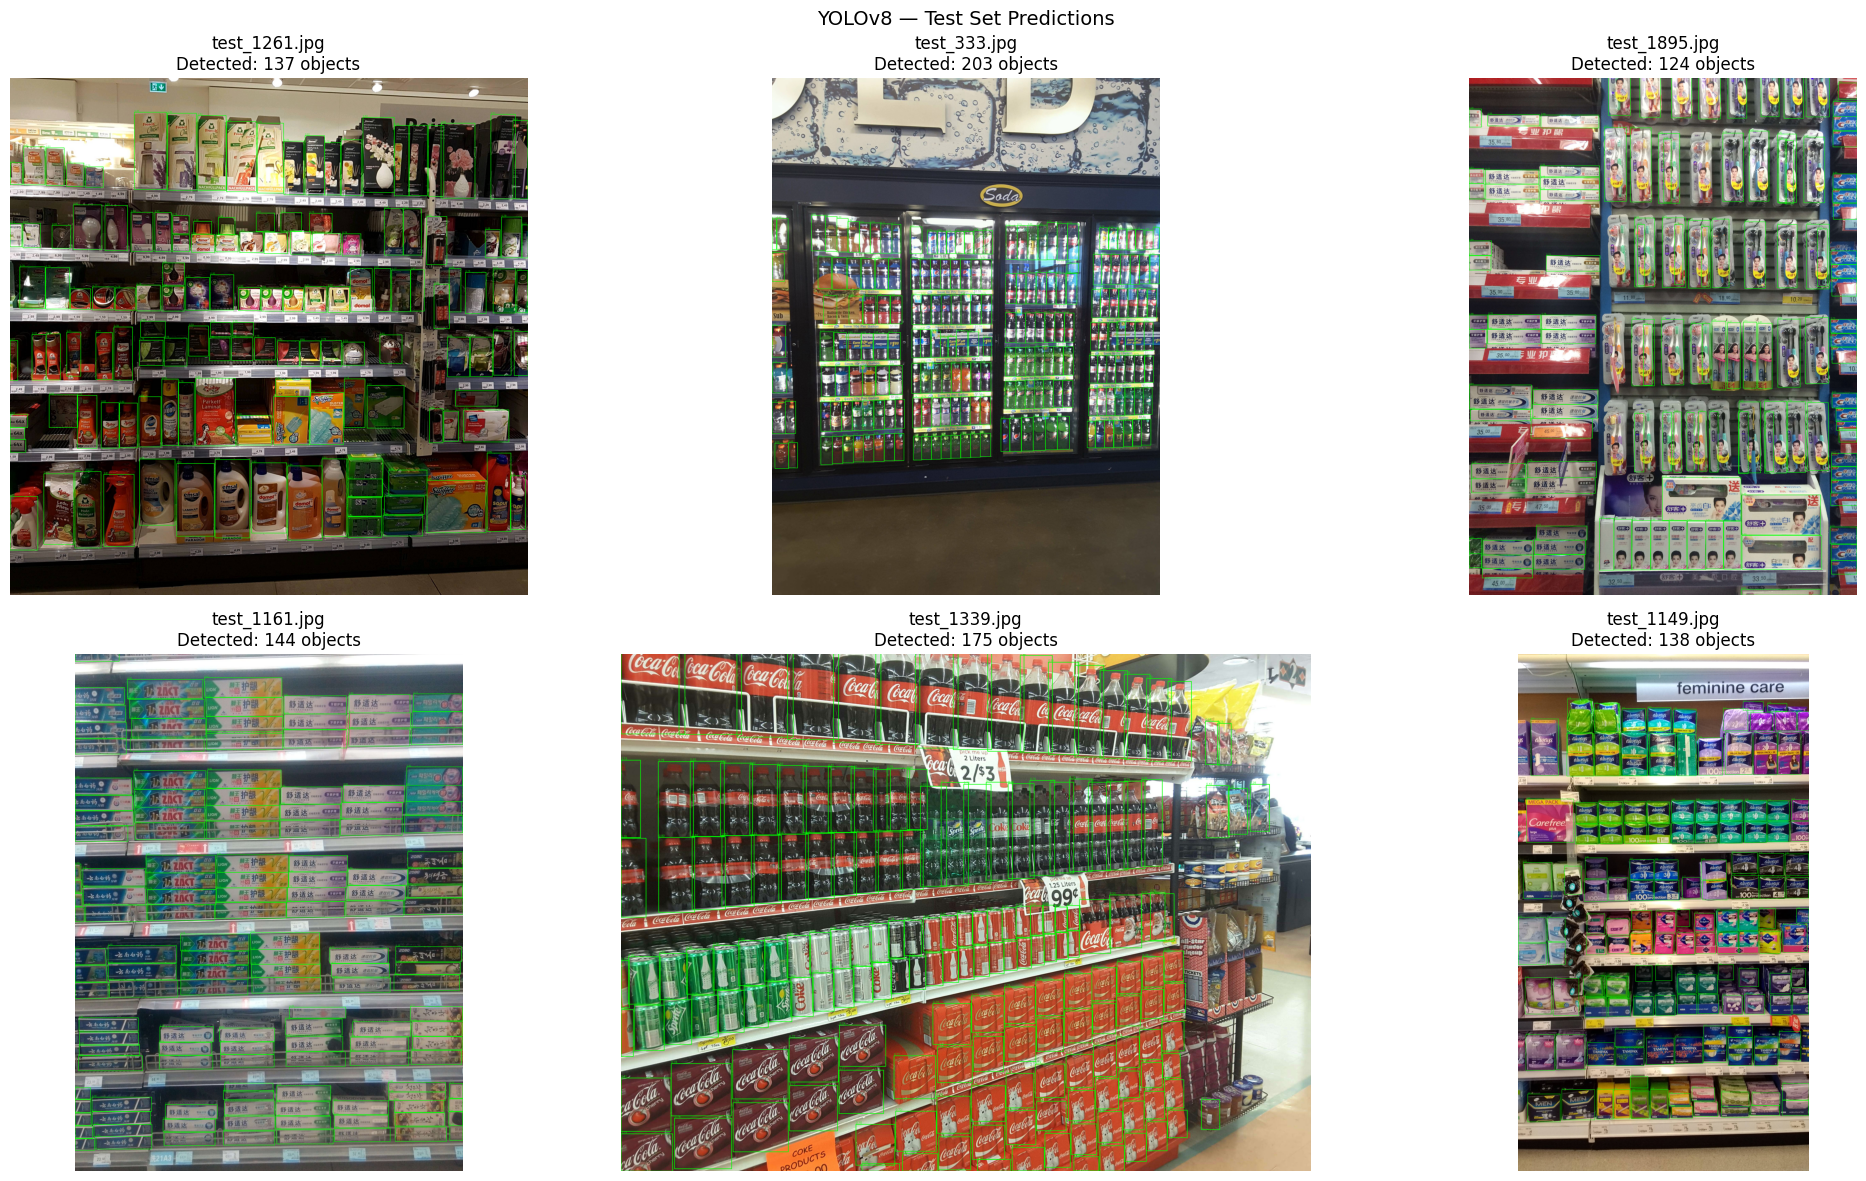

In [37]:
# ============================================================
# CELL 3 - Visual test on random test images
# ============================================================
test_imgs = os.listdir(f"{dataset_path}/images/test")
samples   = random.sample(test_imgs, 6)

fig, axes = plt.subplots(2, 3, figsize=(22, 12))

for ax, fname in zip(axes.flat, samples):
    img_path = f"{dataset_path}/images/test/{fname}"

    result = model(img_path, conf=0.25, iou=0.45, verbose=False)[0]

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    for box, conf in zip(result.boxes.xyxy.cpu().numpy(),
                         result.boxes.conf.cpu().numpy()):
        x1, y1, x2, y2 = map(int, box)
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(img, f"{conf:.2f}", (x1, y1 - 4),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 255, 0), 1)

    ax.imshow(img)
    ax.set_title(f"{fname}\nDetected: {len(result.boxes)} objects")
    ax.axis("off")

plt.suptitle("YOLOv8 — Test Set Predictions", fontsize=14)
plt.tight_layout()
plt.savefig("/kaggle/working/test_predictions.png", dpi=150)
plt.show()

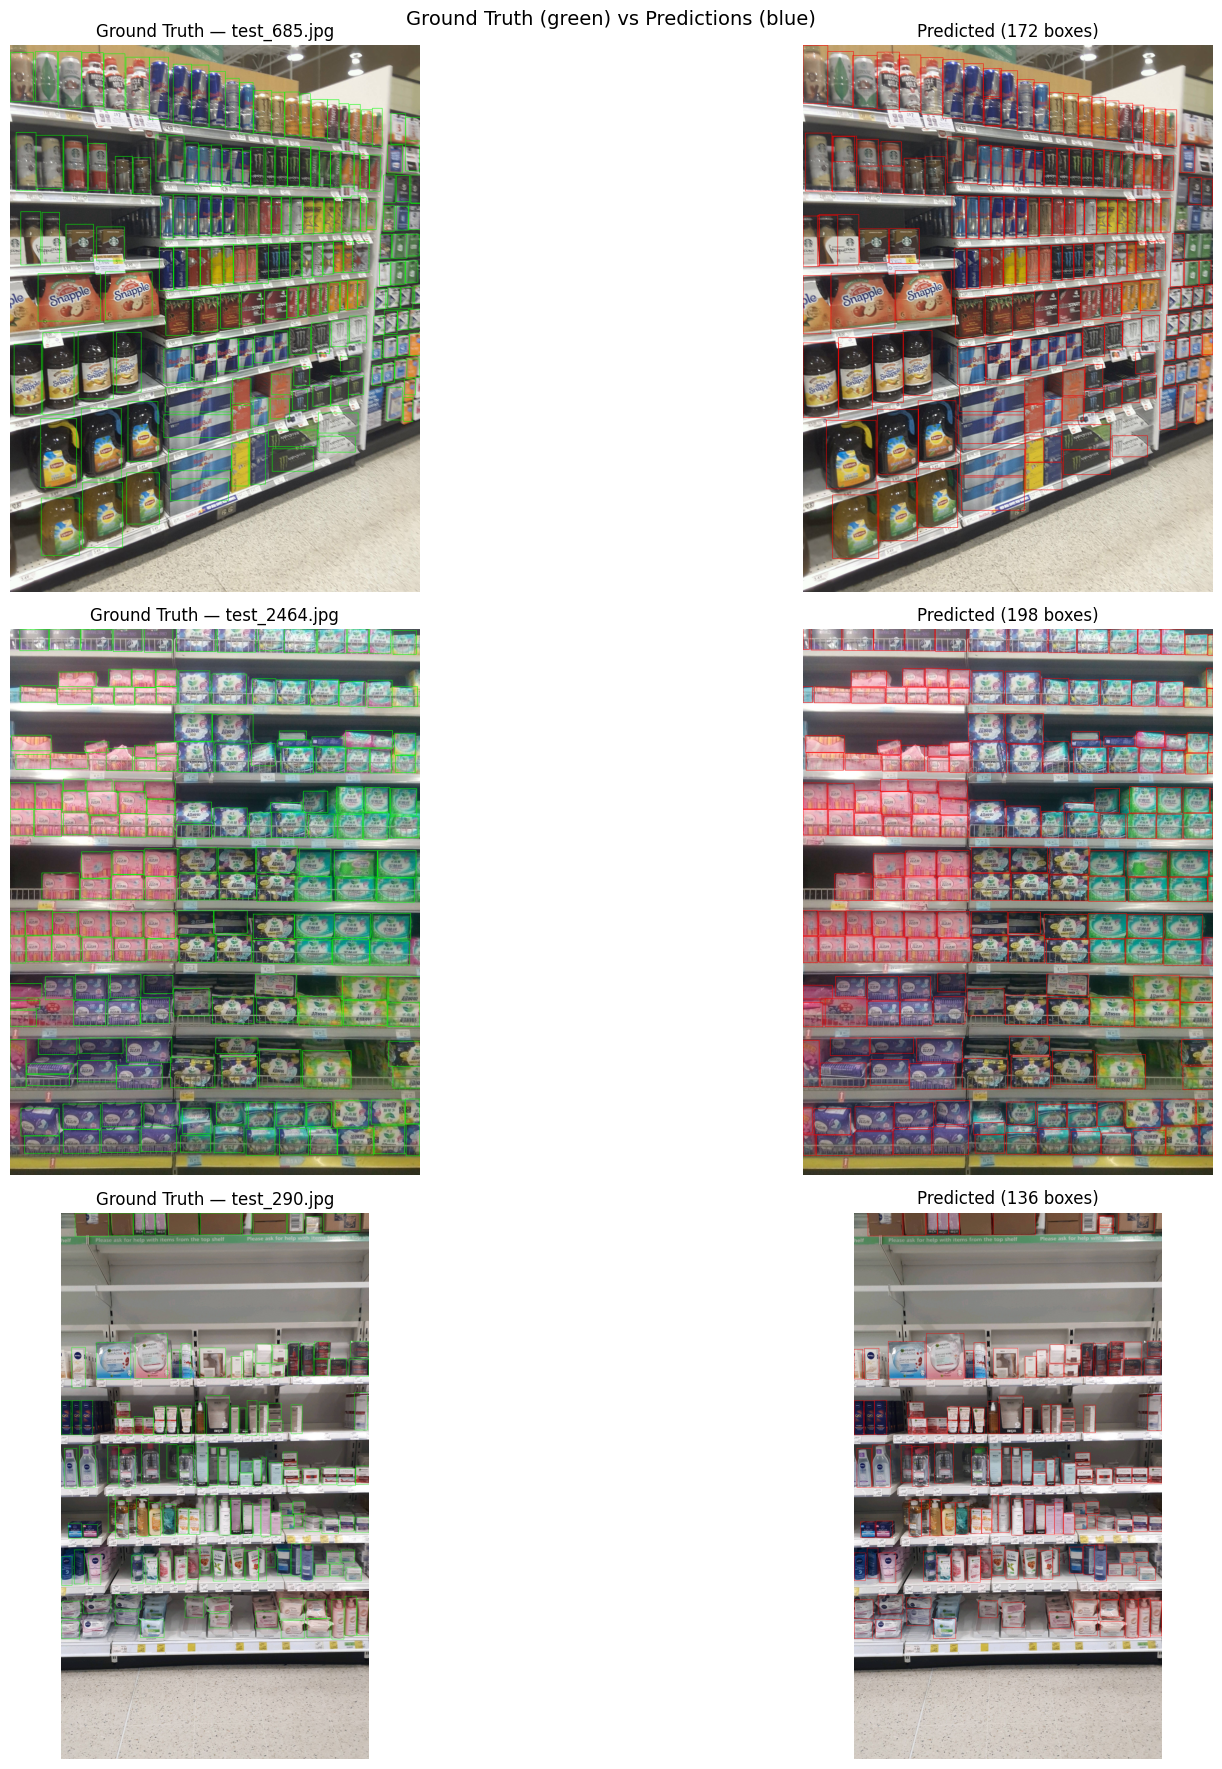

In [38]:
# ============================================================
# CELL 4 - Compare predictions vs ground truth side by side
# ============================================================
def draw_boxes(img, boxes, color, label_prefix=""):
    for box in boxes:
        x1, y1, x2, y2 = map(int, box)
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
    return img

samples_gt = random.sample(test_imgs, 3)
fig, axes  = plt.subplots(3, 2, figsize=(20, 18))

for row, fname in enumerate(samples_gt):
    img_path = f"{dataset_path}/images/test/{fname}"
    lbl_path = f"{dataset_path}/labels/test/{fname.replace('.jpg', '.txt')}"

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    # Ground truth
    gt_img = img.copy()
    if os.path.exists(lbl_path):
        with open(lbl_path) as f:
            for line in f:
                _, cx, cy, bw, bh = map(float, line.strip().split())
                x1 = int((cx - bw/2) * w)
                y1 = int((cy - bh/2) * h)
                x2 = int((cx + bw/2) * w)
                y2 = int((cy + bh/2) * h)
                cv2.rectangle(gt_img, (x1,y1), (x2,y2), (0, 255, 0), 2)

    # Predictions
    pred_img = img.copy()
    result   = model(img_path, conf=0.25, iou=0.45, verbose=False)[0]
    for box in result.boxes.xyxy.cpu().numpy():
        x1, y1, x2, y2 = map(int, box)
        cv2.rectangle(pred_img, (x1,y1), (x2,y2), (255, 0, 0), 2)

    axes[row][0].imshow(gt_img)
    axes[row][0].set_title(f"Ground Truth — {fname}")
    axes[row][0].axis("off")

    axes[row][1].imshow(pred_img)
    axes[row][1].set_title(f"Predicted ({len(result.boxes)} boxes)")
    axes[row][1].axis("off")

plt.suptitle("Ground Truth (green) vs Predictions (blue)", fontsize=14)
plt.tight_layout()
plt.savefig("/kaggle/working/gt_vs_pred.png", dpi=150)
plt.show()

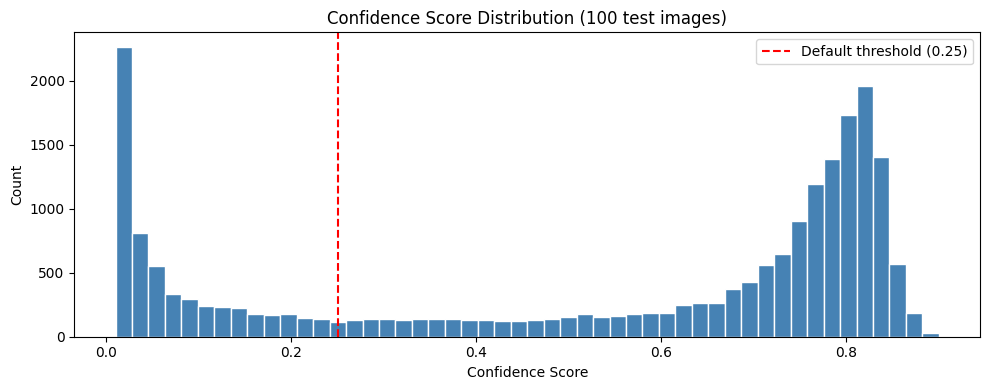

Total detections (conf > 0.01): 20919
Mean confidence: 0.533
Detections above 0.25: 15102
Detections above 0.50: 13247


In [39]:
# ============================================================
# CELL 5 - Confidence score distribution
# ============================================================
all_confs = []
sample_for_dist = random.sample(test_imgs, 100)

for fname in sample_for_dist:
    img_path = f"{dataset_path}/images/test/{fname}"
    result   = model(img_path, conf=0.01, verbose=False)[0]  # low conf to capture all
    confs    = result.boxes.conf.cpu().numpy().tolist()
    all_confs.extend(confs)

plt.figure(figsize=(10, 4))
plt.hist(all_confs, bins=50, color="steelblue", edgecolor="white")
plt.axvline(0.25, color="red", linestyle="--", label="Default threshold (0.25)")
plt.xlabel("Confidence Score")
plt.ylabel("Count")
plt.title("Confidence Score Distribution (100 test images)")
plt.legend()
plt.tight_layout()
plt.savefig("/kaggle/working/confidence_dist.png", dpi=150)
plt.show()

print(f"Total detections (conf > 0.01): {len(all_confs)}")
print(f"Mean confidence: {np.mean(all_confs):.3f}")
print(f"Detections above 0.25: {sum(c > 0.25 for c in all_confs)}")
print(f"Detections above 0.50: {sum(c > 0.50 for c in all_confs)}")

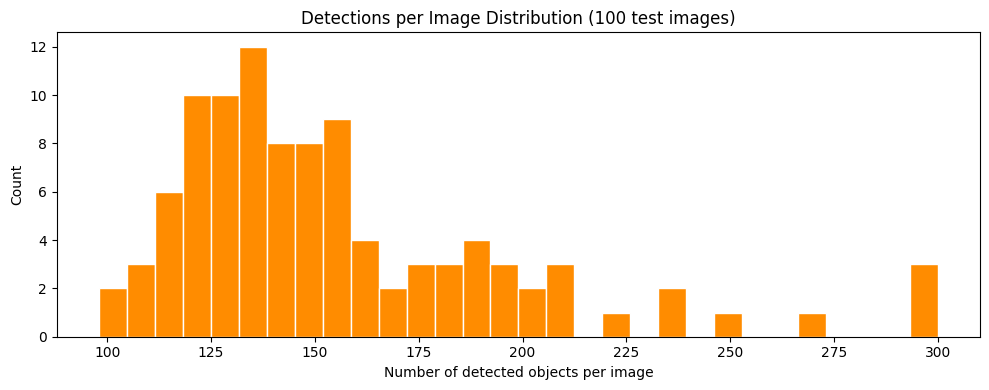

Average detections per image: 155.7
Min: 98 | Max: 300


In [40]:
# ============================================================
# CELL 6 - Detection count distribution (boxes per image)
# ============================================================
box_counts = []
sample_for_count = random.sample(test_imgs, 100)

for fname in sample_for_count:
    img_path = f"{dataset_path}/images/test/{fname}"
    result   = model(img_path, conf=0.25, verbose=False)[0]
    box_counts.append(len(result.boxes))

plt.figure(figsize=(10, 4))
plt.hist(box_counts, bins=30, color="darkorange", edgecolor="white")
plt.xlabel("Number of detected objects per image")
plt.ylabel("Count")
plt.title("Detections per Image Distribution (100 test images)")
plt.tight_layout()
plt.savefig("/kaggle/working/detections_per_image.png", dpi=150)
plt.show()

print(f"Average detections per image: {np.mean(box_counts):.1f}")
print(f"Min: {min(box_counts)} | Max: {max(box_counts)}")

In [41]:
# ============================================================
# CELL 7 - Save all plots as a zip for download
# ============================================================
import shutil

shutil.make_archive("/kaggle/working/test_results", "zip", "/kaggle/working",
                    base_dir=None)

files = ["test_predictions.png", "gt_vs_pred.png",
         "confidence_dist.png",  "detections_per_image.png"]

print("Generated files:")
for f in files:
    path = f"/kaggle/working/{f}"
    if os.path.exists(path):
        size = os.path.getsize(path) / 1e3
        print(f"  {f} ({size:.0f} KB)")

print("\nDownload from Output tab in right sidebar")

RuntimeError: File size too large, try using force_zip64